# 共识声誉计算演示

本 notebook 用于配合论文中“共识声誉的计算”章节，对本系统中的主要变量、参数和状态变化进行可视化说明。演示严格按照代码中的计算口径构造，包括凭证分数截断、账户声誉贡献函数、投票权重上限、原始加权投票和、累计权重、展示分归一化以及贝叶斯平滑等过程。

本 notebook 只用于机制解释与论文配图，不直接连接链上节点，也不改变系统状态。

In [34]:
import importlib.util

import math
from dataclasses import dataclass
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

# Parameters used by contracts/scripts/deploy.ts and apps/web/composables/useChain.ts
ALPHA = 10
S_MIN = -100
S_MAX = 1000
W_MAX = 50
K = 2
C_PHI = 200
MU_0 = 50
LAMBDA = 12
KAPPA = 20

def clamp(value, lo, hi):
    return min(max(value, lo), hi)

def phi(score, k=K, c_phi=C_PHI):
    if score <= 0:
        return 0
    return min(k * score, c_phi)

def weight_of(reputation, w_max=W_MAX):
    if reputation <= 0:
        return 1
    return min(reputation, w_max)

def display_label(score):
    if score >= 85:
        return '信誉极好'
    if score >= 70:
        return '信誉良好'
    if score >= 55:
        return '信誉稳定'
    if score >= 40:
        return '信誉一般'
    return '信誉待观察'

def display_metrics(raw_vote_sum, weight_sum, vote_count, alpha=ALPHA, mu_0=MU_0, lam=LAMBDA, kappa=KAPPA):
    normalized_mean = clamp(raw_vote_sum / (alpha * weight_sum), -1, 1) if weight_sum > 0 else 0
    base_display_score = clamp(mu_0 * (1 + normalized_mean), 0, 100)
    display_score = (lam * mu_0 + vote_count * base_display_score) / (lam + vote_count)
    display_stars = clamp(display_score / kappa, 0, 5)
    return normalized_mean, base_display_score, display_score, display_stars, display_label(display_score)

@dataclass
class CredentialState:
    score: int = 0
    raw_vote_sum: int = 0
    weight_sum: int = 0
    vote_count: int = 0

def apply_vote(state, voter_reputation, direction, alpha=ALPHA, s_min=S_MIN, s_max=S_MAX, w_max=W_MAX):
    weight = weight_of(voter_reputation, w_max)
    delta = alpha * weight * direction
    old_score = state.score
    new_score = clamp(old_score + delta, s_min, s_max)
    rep_delta = phi(new_score) - phi(old_score)
    return CredentialState(
        score=new_score,
        raw_vote_sum=state.raw_vote_sum + delta,
        weight_sum=state.weight_sum + weight,
        vote_count=state.vote_count + 1,
    ), {
        'weight': weight,
        'delta': delta,
        'old_score': old_score,
        'new_score': new_score,
        'owner_reputation_delta': rep_delta,
    }

def simulate_votes(voter_reputations: Iterable[int], directions: Iterable[int], **kwargs):
    state = CredentialState()
    rows = []
    for i, (rep, direction) in enumerate(zip(voter_reputations, directions), start=1):
        state, detail = apply_vote(state, rep, direction, **kwargs)
        normalized_mean, base_score, display_score, stars, label = display_metrics(
            state.raw_vote_sum, state.weight_sum, state.vote_count,
            alpha=kwargs.get('alpha', ALPHA)
        )
        rows.append({
            'vote_index': i,
            'voter_reputation': rep,
            'direction': direction,
            'weight': detail['weight'],
            'delta': detail['delta'],
            'score': state.score,
            'owner_reputation_delta': detail['owner_reputation_delta'],
            'raw_vote_sum': state.raw_vote_sum,
            'weight_sum': state.weight_sum,
            'vote_count': state.vote_count,
            'normalized_mean': normalized_mean,
            'base_display_score': base_score,
            'display_score': display_score,
            'display_stars': stars,
            'display_label': label,
        })
    return pd.DataFrame(rows)

## 去中心化共识声誉机制

本系统的共识声誉不是由单一机构直接给出，而是由账户、凭证和投票事件共同形成。账户持有凭证，凭证接受其他账户的评价，评价结果改变凭证分数，凭证分数再通过贡献函数影响持有人账户声誉，账户声誉又会影响该账户未来投票时的权重。下面的示意图和仿真表展示了这一反馈关系。

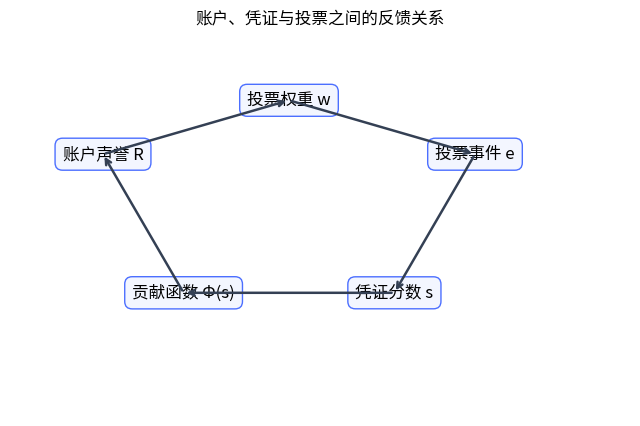

,vote_index,voter_reputation,direction,weight,delta,score,owner_reputation_delta,display_score,display_label
0,1,0,1,1,10,10,20,53.846154,信誉一般
1,2,0,1,1,10,20,20,57.142857,信誉稳定
2,3,60,1,50,500,520,160,60.000000,信誉稳定
3,4,180,-1,50,-500,20,-160,50.245098,信誉一般
4,5,20,1,20,200,220,160,52.651880,信誉一般
5,6,0,-1,1,-10,210,0,52.845528,信誉一般


In [35]:
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.axis('off')

nodes = {
    '账户声誉 R': (0.15, 0.68),
    '投票权重 w': (0.45, 0.82),
    '投票事件 e': (0.75, 0.68),
    '凭证分数 s': (0.62, 0.32),
    '贡献函数 Φ(s)': (0.28, 0.32),
}
for label, (x, y) in nodes.items():
    ax.text(x, y, label, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.45', fc='#f3f6ff', ec='#4c6fff'))

arrows = [
    ('账户声誉 R', '投票权重 w'),
    ('投票权重 w', '投票事件 e'),
    ('投票事件 e', '凭证分数 s'),
    ('凭证分数 s', '贡献函数 Φ(s)'),
    ('贡献函数 Φ(s)', '账户声誉 R'),
]
for a, b in arrows:
    x1, y1 = nodes[a]
    x2, y2 = nodes[b]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.8, color='#344054'))

plt.title('账户、凭证与投票之间的反馈关系')
plt.show()

demo = simulate_votes([0, 0, 60, 180, 20, 0], [1, 1, 1, -1, 1, -1])
demo[['vote_index', 'voter_reputation', 'direction', 'weight', 'delta', 'score', 'owner_reputation_delta', 'display_score', 'display_label']]


## 账户共识声誉

账户声誉由账户持有凭证的贡献值累加得到。凭证分数非正时，贡献为零；凭证分数为正时，贡献随分数线性增加，并在单张凭证贡献上限处停止增长。该设计意味着一个账户可以通过获得多张被认可的凭证逐步积累声誉，但不能依赖单张极高分凭证无限放大自身投票权。

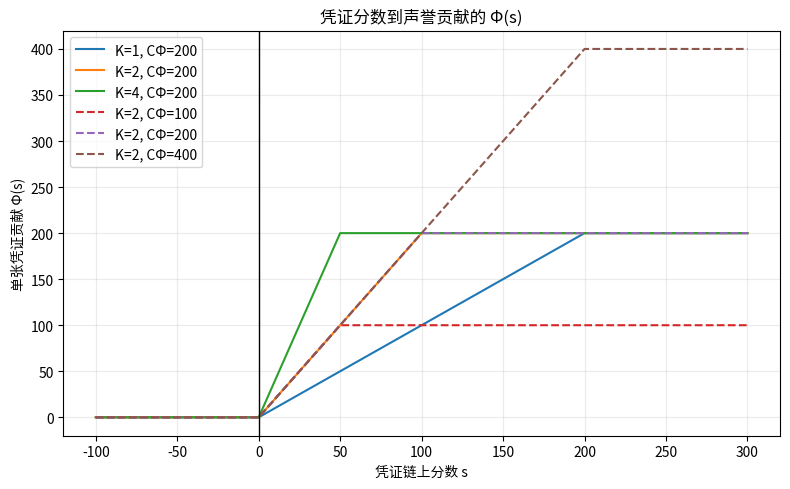

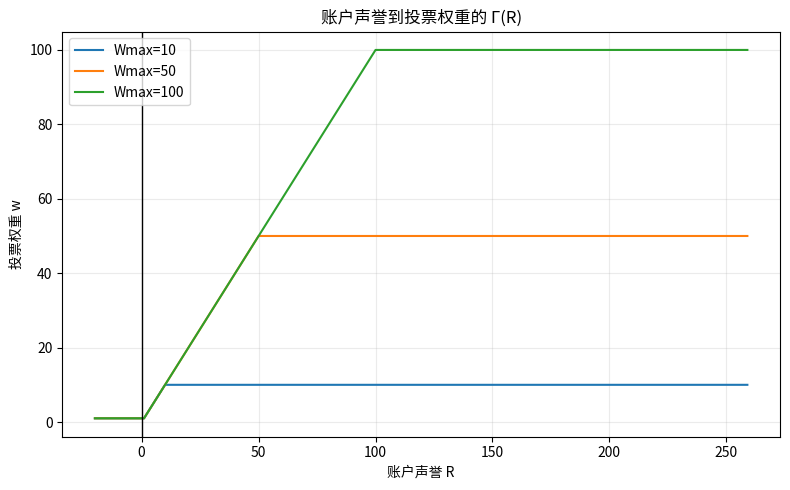

In [36]:
scores = np.arange(S_MIN, 301)

plt.figure(figsize=(8, 5))
for k in [1, K, 4]:
    plt.plot(scores, [phi(s, k=k, c_phi=C_PHI) for s in scores], label=f'K={k}, CΦ={C_PHI}')
for c_phi in [100, C_PHI, 400]:
    plt.plot(scores, [phi(s, k=K, c_phi=c_phi) for s in scores], '--', label=f'K={K}, CΦ={c_phi}')
plt.axvline(0, color='black', lw=1)
plt.title('凭证分数到声誉贡献的 Φ(s)')
plt.xlabel('凭证链上分数 s')
plt.ylabel('单张凭证贡献 Φ(s)')
plt.legend()
plt.tight_layout()
plt.show()

reputations = np.arange(-20, 260)
plt.figure(figsize=(8, 5))
for w_max in [10, W_MAX, 100]:
    plt.plot(reputations, [weight_of(r, w_max=w_max) for r in reputations], label=f'Wmax={w_max}')
plt.axvline(0, color='black', lw=1)
plt.title('账户声誉到投票权重的 Γ(R)')
plt.xlabel('账户声誉 R')
plt.ylabel('投票权重 w')
plt.legend()
plt.tight_layout()
plt.show()


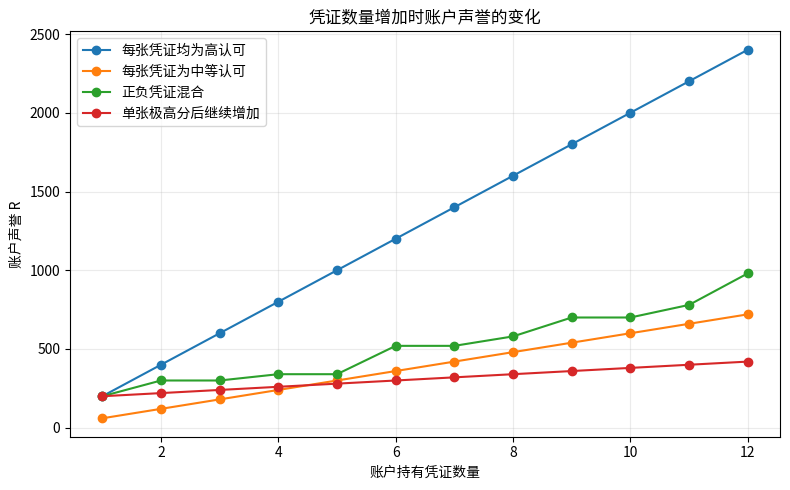

In [37]:
patterns = {
    '每张凭证均为高认可': [100] * 12,
    '每张凭证为中等认可': [30] * 12,
    '正负凭证混合': [100, 50, -40, 20, 0, 90, -20, 30, 60, -80, 40, 110],
    '单张极高分后继续增加': [1000] + [10] * 11,
}

plt.figure(figsize=(8, 5))
for name, credential_scores in patterns.items():
    reputation_trace = []
    total = 0
    for s in credential_scores:
        total += phi(s)
        reputation_trace.append(total)
    x = np.arange(1, len(credential_scores) + 1)
    plt.plot(x, reputation_trace, marker='o', label=name)

plt.title('凭证数量增加时账户声誉的变化')
plt.xlabel('账户持有凭证数量')
plt.ylabel('账户声誉 R')
plt.legend()
plt.tight_layout()
plt.show()


## 凭证共识声誉

凭证共识声誉面向单张凭证。链上分数 `score` 会被截断在 `[S_min, S_max]` 区间内，而 `raw_vote_sum` 保留未截断的累计加权投票历史。下面同时展示单张凭证在全正向、全负向、正负混合以及高声誉账户参与时的变化。

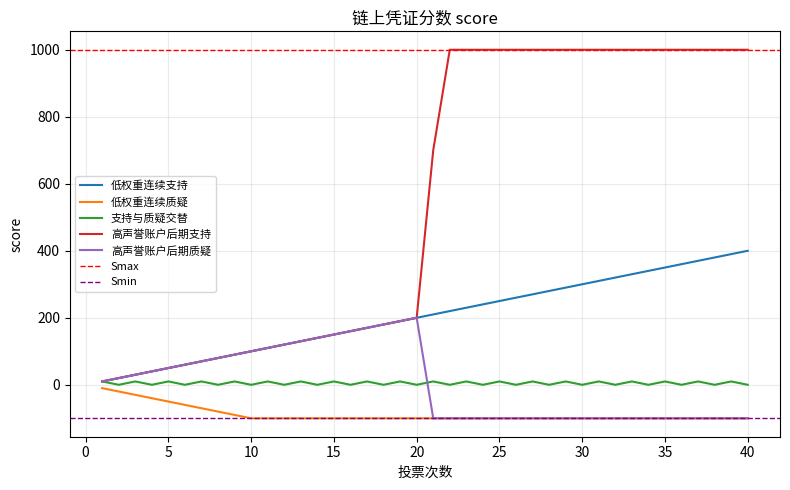

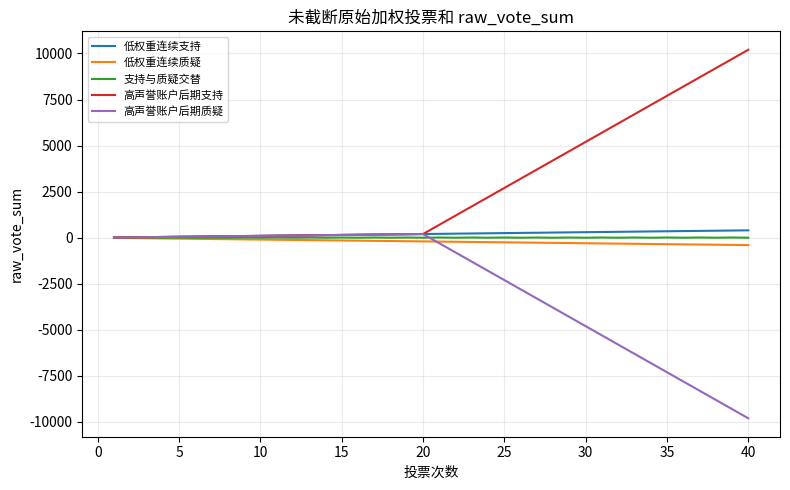

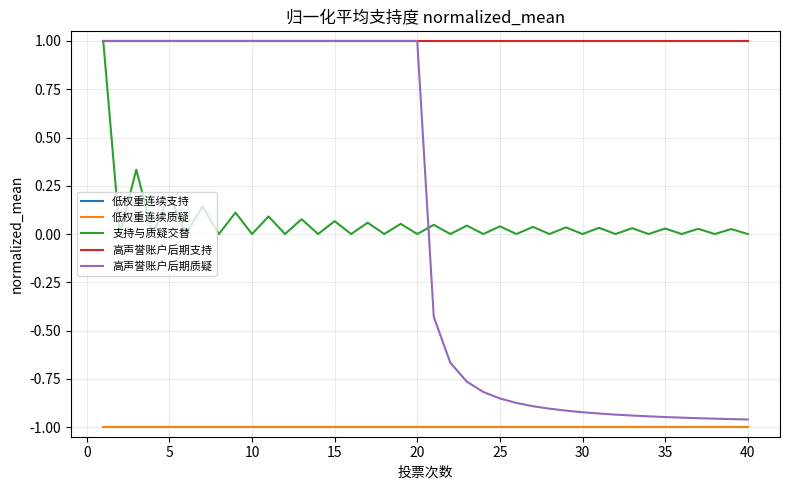

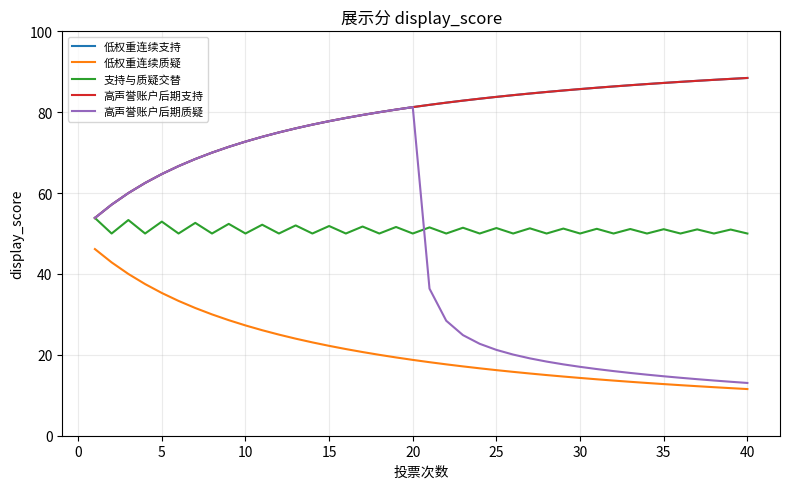

In [38]:
scenarios = {
    '低权重连续支持': simulate_votes([0] * 40, [1] * 40),
    '低权重连续质疑': simulate_votes([0] * 40, [-1] * 40),
    '支持与质疑交替': simulate_votes([0] * 40, [1, -1] * 20),
    '高声誉账户后期支持': simulate_votes([0] * 20 + [80] * 20, [1] * 40),
    '高声誉账户后期质疑': simulate_votes([0] * 20 + [80] * 20, [1] * 20 + [-1] * 20),
}

plt.figure(figsize=(8, 5))
for name, df in scenarios.items():
    plt.plot(df['vote_index'], df['score'], label=name)
plt.axhline(S_MAX, color='red', linestyle='--', lw=1, label='Smax')
plt.axhline(S_MIN, color='purple', linestyle='--', lw=1, label='Smin')
plt.title('链上凭证分数 score')
plt.xlabel('投票次数')
plt.ylabel('score')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for name, df in scenarios.items():
    plt.plot(df['vote_index'], df['raw_vote_sum'], label=name)
plt.title('未截断原始加权投票和 raw_vote_sum')
plt.xlabel('投票次数')
plt.ylabel('raw_vote_sum')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for name, df in scenarios.items():
    plt.plot(df['vote_index'], df['normalized_mean'], label=name)
plt.title('归一化平均支持度 normalized_mean')
plt.xlabel('投票次数')
plt.ylabel('normalized_mean')
plt.ylim(-1.05, 1.05)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for name, df in scenarios.items():
    plt.plot(df['vote_index'], df['display_score'], label=name)
plt.title('展示分 display_score')
plt.xlabel('投票次数')
plt.ylabel('display_score')
plt.ylim(0, 100)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 投票

一次有效投票的直接影响由 `delta = alpha × weight × direction` 决定。`alpha` 决定基础步长，`weight` 由投票者声誉产生并受 `W_max` 约束，`direction` 只能取 `+1` 或 `-1`。下面分别观察基础影响系数、投票者声誉和权重上限对单次投票增量的影响。

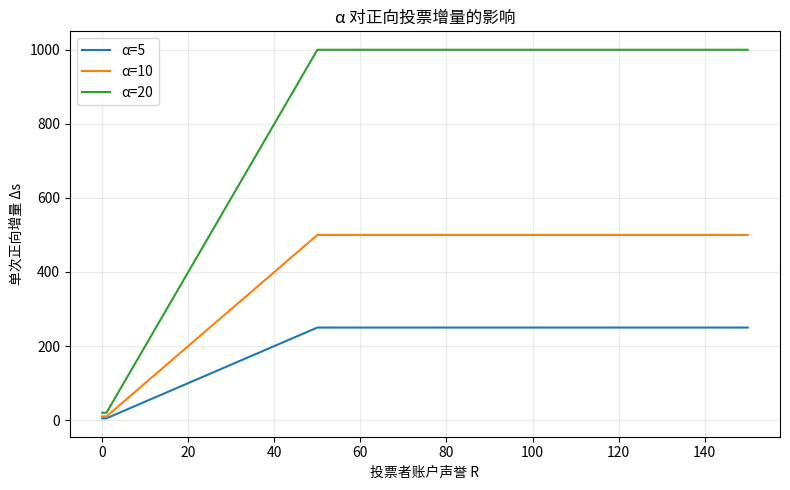

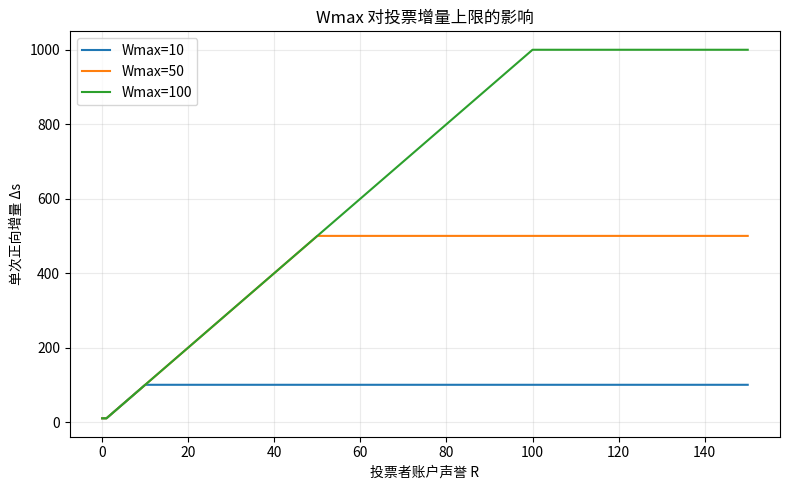

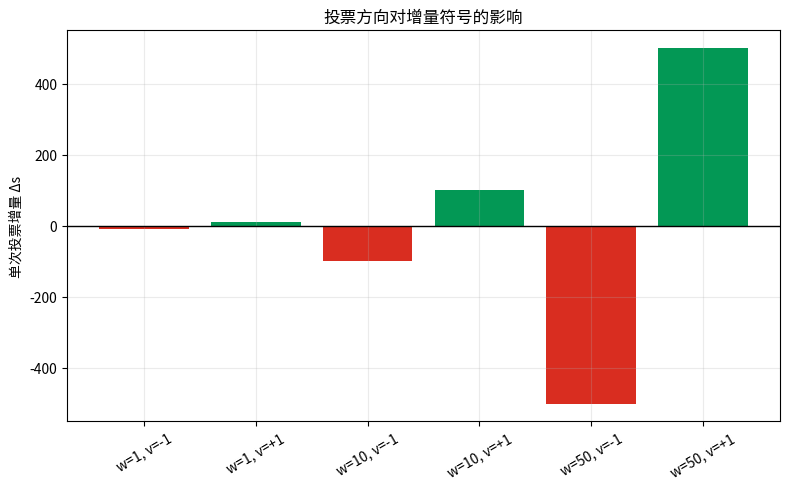

In [39]:
voter_reps = np.arange(0, 151)

plt.figure(figsize=(8, 5))
for alpha in [5, ALPHA, 20]:
    deltas = [alpha * weight_of(r) for r in voter_reps]
    plt.plot(voter_reps, deltas, label=f'α={alpha}')
plt.title('α 对正向投票增量的影响')
plt.xlabel('投票者账户声誉 R')
plt.ylabel('单次正向增量 Δs')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for w_max in [10, W_MAX, 100]:
    deltas = [ALPHA * weight_of(r, w_max=w_max) for r in voter_reps]
    plt.plot(voter_reps, deltas, label=f'Wmax={w_max}')
plt.title('Wmax 对投票增量上限的影响')
plt.xlabel('投票者账户声誉 R')
plt.ylabel('单次正向增量 Δs')
plt.legend()
plt.tight_layout()
plt.show()

directions = [-1, 1]
weights = [1, 10, W_MAX]
bar_labels = [f'w={w}, v={d:+d}' for w in weights for d in directions]
bar_values = [ALPHA * w * d for w in weights for d in directions]
plt.figure(figsize=(8, 5))
plt.bar(bar_labels, bar_values, color=['#d92d20' if v < 0 else '#039855' for v in bar_values])
plt.axhline(0, color='black', lw=1)
plt.title('投票方向对增量符号的影响')
plt.ylabel('单次投票增量 Δs')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


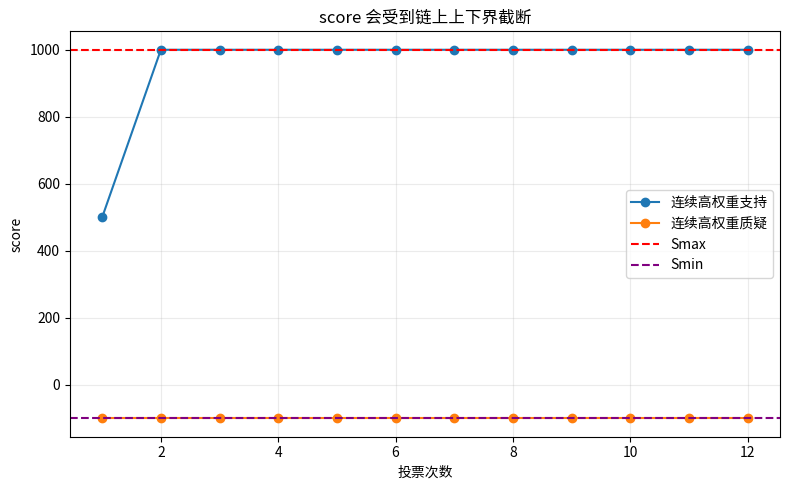

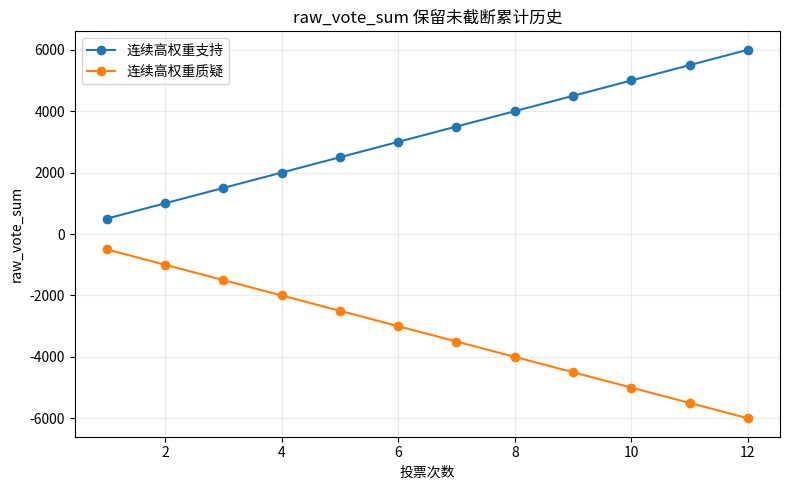

,scenario,vote_index,weight,delta,score,raw_vote_sum,owner_reputation_delta
4,连续高权重质疑,5,50,-500,-100,-2500,0
5,连续高权重质疑,6,50,-500,-100,-3000,0
6,连续高权重质疑,7,50,-500,-100,-3500,0
7,连续高权重质疑,8,50,-500,-100,-4000,0
8,连续高权重质疑,9,50,-500,-100,-4500,0
9,连续高权重质疑,10,50,-500,-100,-5000,0
10,连续高权重质疑,11,50,-500,-100,-5500,0
11,连续高权重质疑,12,50,-500,-100,-6000,0


In [40]:
# 展示 score 截断与 raw_vote_sum 不截断之间的差异。
df_positive_saturation = simulate_votes([500] * 12, [1] * 12)
df_negative_saturation = simulate_votes([500] * 12, [-1] * 12)

plt.figure(figsize=(8, 5))
for name, df in {'连续高权重支持': df_positive_saturation, '连续高权重质疑': df_negative_saturation}.items():
    plt.plot(df['vote_index'], df['score'], marker='o', label=name)
plt.axhline(S_MAX, color='red', linestyle='--', label='Smax')
plt.axhline(S_MIN, color='purple', linestyle='--', label='Smin')
plt.title('score 会受到链上上下界截断')
plt.xlabel('投票次数')
plt.ylabel('score')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for name, df in {'连续高权重支持': df_positive_saturation, '连续高权重质疑': df_negative_saturation}.items():
    plt.plot(df['vote_index'], df['raw_vote_sum'], marker='o', label=name)
plt.title('raw_vote_sum 保留未截断累计历史')
plt.xlabel('投票次数')
plt.ylabel('raw_vote_sum')
plt.legend()
plt.tight_layout()
plt.show()

pd.concat([
    df_positive_saturation.assign(scenario='连续高权重支持'),
    df_negative_saturation.assign(scenario='连续高权重质疑')
])[['scenario', 'vote_index', 'weight', 'delta', 'score', 'raw_vote_sum', 'owner_reputation_delta']].tail(8)


## 投票的约束

投票约束决定哪些调用能够进入声誉计算。只有通过 KYC、目标凭证存在、凭证未吊销、投票方向合法、未重复投票且不是为本人凭证投票时，状态才会更新。下面用场景化数据展示各类约束的过滤效果，并演示被拒绝投票不会改变 `score`、`raw_vote_sum`、`weight_sum` 和 `vote_count`。

In [41]:
constraint_cases = pd.DataFrame([
    {'case': '有效投票', 'kyc': True, 'exists': True, 'revoked': False, 'direction_ok': True, 'not_self': True, 'not_repeated': True},
    {'case': '未通过KYC', 'kyc': False, 'exists': True, 'revoked': False, 'direction_ok': True, 'not_self': True, 'not_repeated': True},
    {'case': '凭证不存在', 'kyc': True, 'exists': False, 'revoked': False, 'direction_ok': True, 'not_self': True, 'not_repeated': True},
    {'case': '凭证已吊销', 'kyc': True, 'exists': True, 'revoked': True, 'direction_ok': True, 'not_self': True, 'not_repeated': True},
    {'case': '方向非法', 'kyc': True, 'exists': True, 'revoked': False, 'direction_ok': False, 'not_self': True, 'not_repeated': True},
    {'case': '自投票', 'kyc': True, 'exists': True, 'revoked': False, 'direction_ok': True, 'not_self': False, 'not_repeated': True},
    {'case': '重复投票', 'kyc': True, 'exists': True, 'revoked': False, 'direction_ok': True, 'not_self': True, 'not_repeated': False},
])
constraint_cases['accepted'] = constraint_cases[['kyc', 'exists', 'direction_ok', 'not_self', 'not_repeated']].all(axis=1) & (~constraint_cases['revoked'])
constraint_cases

,case,kyc,exists,revoked,direction_ok,not_self,not_repeated,accepted
0,有效投票,True,True,False,True,True,True,True
1,未通过KYC,False,True,False,True,True,True,False
2,凭证不存在,True,False,False,True,True,True,False
3,凭证已吊销,True,True,True,True,True,True,False
4,方向非法,True,True,False,False,True,True,False
5,自投票,True,True,False,True,False,True,False
6,重复投票,True,True,False,True,True,False,False


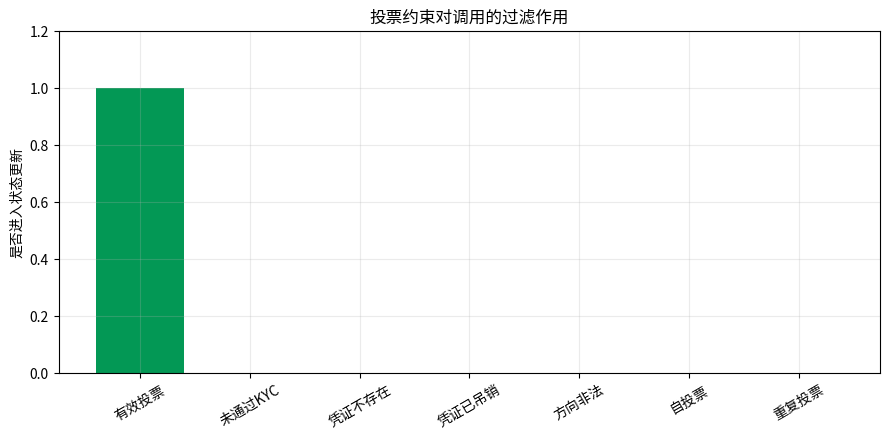

,event,accepted,score,raw_vote_sum,weight_sum,vote_count
0,有效投票,True,200,200,20,1
1,重复投票,False,200,200,20,1
2,未通过KYC,False,200,200,20,1
3,凭证已吊销,False,200,200,20,1
4,另一个有效投票,True,-100,-300,70,2


In [42]:
plt.figure(figsize=(9, 4.5))
colors = ['#039855' if ok else '#d92d20' for ok in constraint_cases['accepted']]
plt.bar(constraint_cases['case'], constraint_cases['accepted'].astype(int), color=colors)
plt.ylim(0, 1.2)
plt.ylabel('是否进入状态更新')
plt.title('投票约束对调用的过滤作用')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

state = CredentialState()
trace = []
events = [
    ('有效投票', True, 20, 1),
    ('重复投票', False, 20, 1),
    ('未通过KYC', False, 80, 1),
    ('凭证已吊销', False, 80, -1),
    ('另一个有效投票', True, 80, -1),
]
for name, accepted, voter_rep, direction in events:
    if accepted:
        state, detail = apply_vote(state, voter_rep, direction)
    trace.append({
        'event': name,
        'accepted': accepted,
        'score': state.score,
        'raw_vote_sum': state.raw_vote_sum,
        'weight_sum': state.weight_sum,
        'vote_count': state.vote_count,
    })
pd.DataFrame(trace)


## 投票基数偏差与统计校正

展示层并不直接使用链上 `score`，而是先用 `raw_vote_sum / (alpha × weight_sum)` 得到归一化平均支持度，再将其映射到百分制基础展示分，最后通过贝叶斯平滑削弱小样本阶段的剧烈波动。下面分别展示样本数量、正负比例、平滑强度和先验均值对展示分的影响。

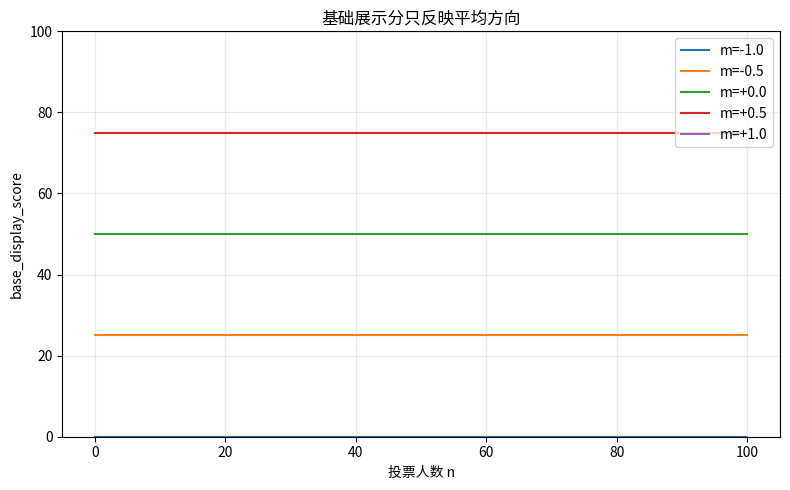

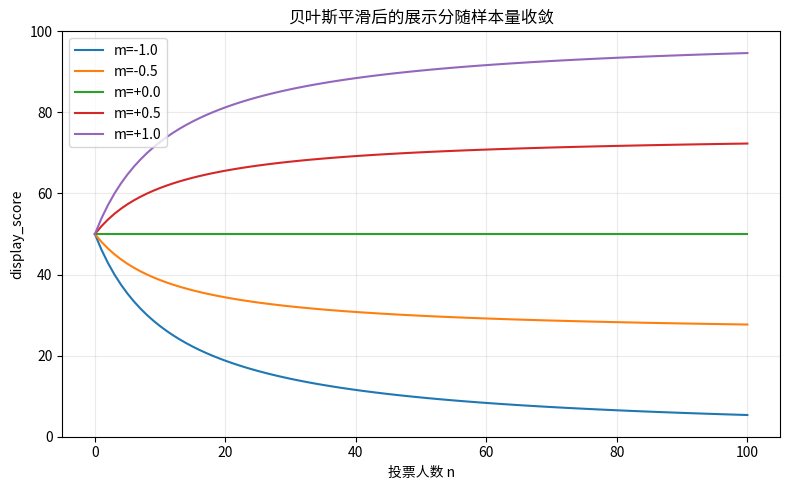

In [43]:
def constant_mean_display(mean, vote_counts, mu_0=MU_0, lam=LAMBDA):
    base = mu_0 * (1 + mean)
    return [(lam * mu_0 + n * base) / (lam + n) for n in vote_counts]

vote_counts = np.arange(0, 101)
means = [-1.0, -0.5, 0.0, 0.5, 1.0]

plt.figure(figsize=(8, 5))
for mean in means:
    plt.plot(vote_counts, [MU_0 * (1 + mean)] * len(vote_counts), label=f'm={mean:+.1f}')
plt.title('基础展示分只反映平均方向')
plt.xlabel('投票人数 n')
plt.ylabel('base_display_score')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for mean in means:
    plt.plot(vote_counts, constant_mean_display(mean, vote_counts), label=f'm={mean:+.1f}')
plt.title('贝叶斯平滑后的展示分随样本量收敛')
plt.xlabel('投票人数 n')
plt.ylabel('display_score')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


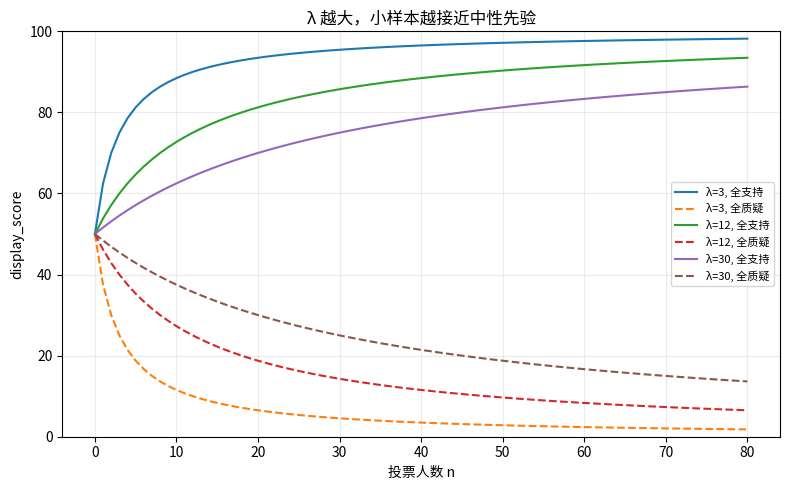

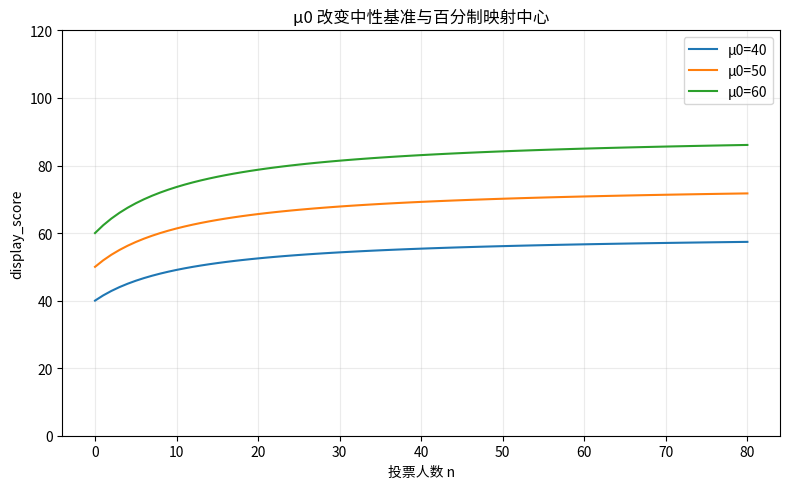

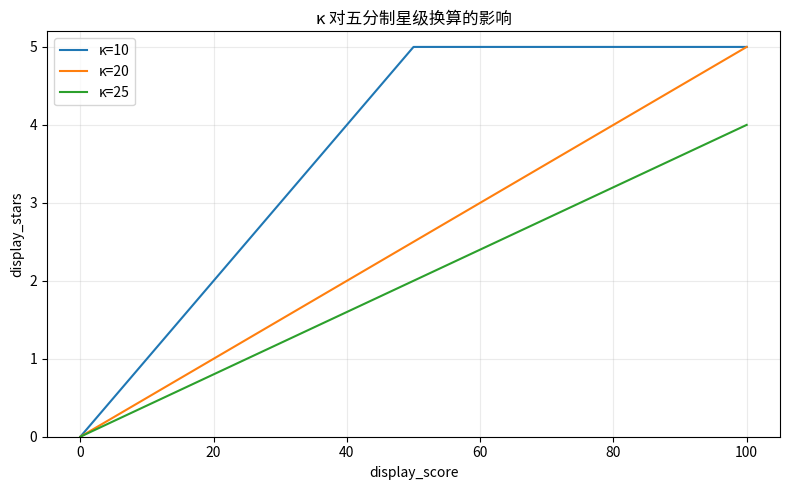

In [44]:
vote_counts = np.arange(0, 81)

plt.figure(figsize=(8, 5))
for lam in [3, LAMBDA, 30]:
    plt.plot(vote_counts, constant_mean_display(1.0, vote_counts, lam=lam), label=f'λ={lam}, 全支持')
    plt.plot(vote_counts, constant_mean_display(-1.0, vote_counts, lam=lam), '--', label=f'λ={lam}, 全质疑')
plt.title('λ 越大，小样本越接近中性先验')
plt.xlabel('投票人数 n')
plt.ylabel('display_score')
plt.ylim(0, 100)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for mu_0 in [40, MU_0, 60]:
    plt.plot(vote_counts, constant_mean_display(0.5, vote_counts, mu_0=mu_0), label=f'μ0={mu_0}')
plt.title('μ0 改变中性基准与百分制映射中心')
plt.xlabel('投票人数 n')
plt.ylabel('display_score')
plt.ylim(0, 120)
plt.legend()
plt.tight_layout()
plt.show()

scores = np.arange(0, 101)
plt.figure(figsize=(8, 5))
for kappa in [10, KAPPA, 25]:
    plt.plot(scores, [clamp(s / kappa, 0, 5) for s in scores], label=f'κ={kappa}')
plt.title('κ 对五分制星级换算的影响')
plt.xlabel('display_score')
plt.ylabel('display_stars')
plt.ylim(0, 5.2)
plt.legend()
plt.tight_layout()
plt.show()


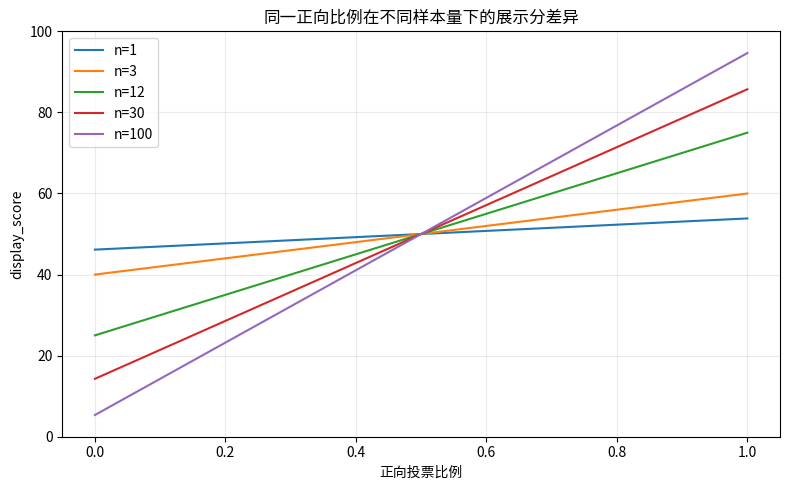

,vote_count,positive_ratio,normalized_mean,base_display_score,display_score,display_stars,display_label
0,1,0.00,-1.0,0.0,46.15,2.31,信誉一般
1,1,0.25,-0.5,25.0,48.08,2.40,信誉一般
2,1,0.50,0.0,50.0,50.00,2.50,信誉一般
3,1,0.75,0.5,75.0,51.92,2.60,信誉一般
4,1,1.00,1.0,100.0,53.85,2.69,信誉一般
5,3,0.00,-1.0,0.0,40.00,2.00,信誉一般
6,3,0.25,-0.5,25.0,45.00,2.25,信誉一般
7,3,0.50,0.0,50.0,50.00,2.50,信誉一般
8,3,0.75,0.5,75.0,55.00,2.75,信誉稳定
9,3,1.00,1.0,100.0,60.00,3.00,信誉稳定


In [45]:
ratios = np.linspace(0, 1, 51)
sample_sizes = [1, 3, 12, 30, 100]

plt.figure(figsize=(8, 5))
for n in sample_sizes:
    display_scores = []
    for positive_ratio in ratios:
        mean = 2 * positive_ratio - 1
        base = MU_0 * (1 + mean)
        display_scores.append((LAMBDA * MU_0 + n * base) / (LAMBDA + n))
    plt.plot(ratios, display_scores, label=f'n={n}')
plt.title('同一正向比例在不同样本量下的展示分差异')
plt.xlabel('正向投票比例')
plt.ylabel('display_score')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

summary_rows = []
for n in sample_sizes:
    for positive_ratio in [0, 0.25, 0.5, 0.75, 1.0]:
        mean = 2 * positive_ratio - 1
        base = MU_0 * (1 + mean)
        score = (LAMBDA * MU_0 + n * base) / (LAMBDA + n)
        summary_rows.append({
            'vote_count': n,
            'positive_ratio': positive_ratio,
            'normalized_mean': mean,
            'base_display_score': base,
            'display_score': round(score, 2),
            'display_stars': round(clamp(score / KAPPA, 0, 5), 2),
            'display_label': display_label(score),
        })
pd.DataFrame(summary_rows)
